In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import smarts_cerebellum.globals as gl

In [55]:
CST_T1  = pd.read_csv(f'{gl.baseDir}/Regression/summary_MNISym_T1_slope.tsv', sep = '\t')   # slope for each subject at L/R CST
CST_GM  = pd.read_csv(f'{gl.baseDir}/Regression/summary_MNISym_GM_slope.tsv', sep = '\t')   # slope for each subject at L/R CST
CST_WM  = pd.read_csv(f'{gl.baseDir}/Regression/summary_MNISym_WM_slope.tsv', sep = '\t')   # slope for each subject at L/R CST
CST_CSF = pd.read_csv(f'{gl.baseDir}/Regression/summary_MNISym_CSF_slope.tsv', sep = '\t')  # slope for each subject at L/R CST

        Source        SS  DF1  DF2        MS         F     p_unc       np2  \
0    isPatient  0.778646    1   45  0.778646  0.078301  0.780896  0.001737   
1   regionname  7.340916    1   45  7.340916  8.817352  0.004771  0.163838   
2  Interaction  4.914379    1   45  4.914379  5.902780  0.019171  0.115962   

   eps  
0  NaN  
1  1.0  
2  NaN  


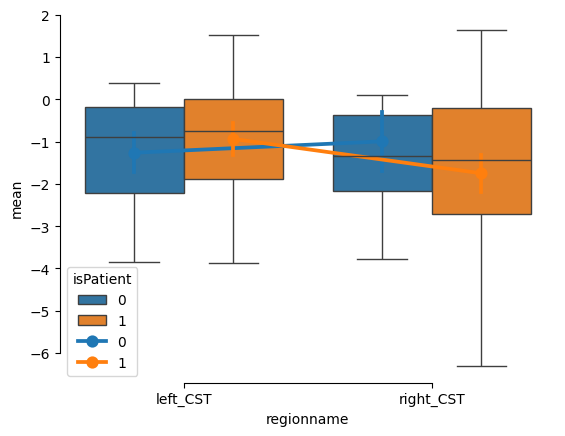

In [58]:
anova  = pg.mixed_anova(data=CST_T1, dv = 'mean', within= 'regionname', between = 'isPatient', subject='subj_id')
print(anova)

fig, ax = plt.subplots()

sns.boxplot(data = CST_T1, x = 'regionname', y = 'mean', hue = 'isPatient', showfliers = False)
#sns.stripplot(data = CST_T1, x = 'regionname', y = 'mean', hue = 'isPatient', dodge=.4)
sns.pointplot(data = CST_T1, x = 'regionname', y = 'mean', hue = 'isPatient', errorbar='se', dodge=.4)
sns.despine(trim = True)
plt.show()

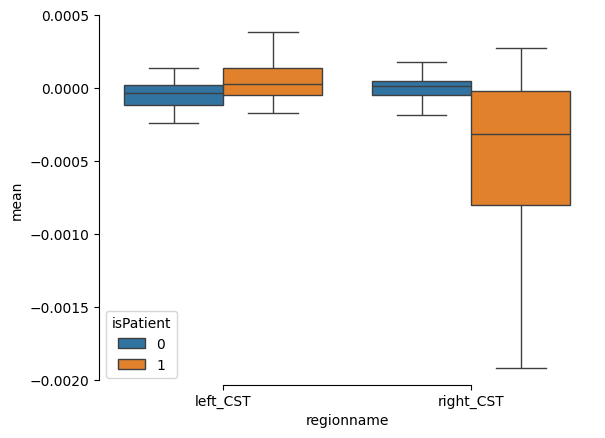

In [43]:
fig, ax = plt.subplots()

sns.boxplot(data = CST_WM, x = 'regionname', y = 'mean', hue = 'isPatient', showfliers = False)
sns.despine(trim = True)
plt.show()

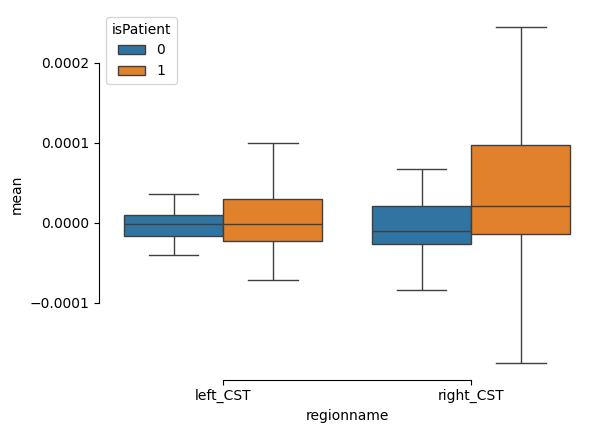

In [44]:
fig, ax = plt.subplots()

sns.boxplot(data = CST_CSF, x = 'regionname', y = 'mean', hue = 'isPatient', showfliers = False)
sns.despine(trim = True)
plt.show()

In [45]:
# independent t-test between patients and controls for each side (wm)
t_val_wm_l, p_val_wm_l = stats.ttest_ind(patients_wm_l, controls_wm_l)
print(f'**Independent t-test between patients, controls: WM CST, left (contralesional)** \n t-value: {t_val_wm_l}, p-value: {p_val_wm_l}')
print('\n')

t_val_wm_r, p_val_wm_r = stats.ttest_ind(patients_wm_r, controls_wm_r)
print(f'**Independent t-test between patients, controls: WM CST, right (ipsilesional)** \n t-value: {t_val_wm_r}, p-value: {p_val_wm_r}')

NameError: name 'patients_wm_l' is not defined

In [ ]:
# paired t-test within patients for each side (wm)
t_val_wm_patients, p_val_wm_patients = stats.ttest_rel(patients_wm_l, patients_wm_r)
print(f'**Independent t-test within patients: WM CST** \n t-value: {t_val_wm_patients}, p-value: {p_val_wm_patients}')
print('\n')

**Independent t-test within patients: WM CST** 
 t-value: 3.983269191913481, p-value: 0.0003165631036364566


